# analysis for first presentation

In [1]:
# imports 
import pandas as pd
import ast

In [27]:
tk = pd.read_csv('tweede_kamer_data.csv', index_col=0)


In [28]:
tk

,title,year,matched_keywords_all,n_hits_body_total,body,original_word_count,type
0,Investeren in Perspectief (Beleidsnota 2018),2018,"['adyen', 'google', 'kunstmatige intelligentie']",1,Ook biedt de agenda kansen aan het bedrijfslev...,29318.0,beleidsstuk
1,Nota Defensie Industrie Strategie,2018,"['drones', 'ai', 'artificiële intelligentie', ...",13,Nederland wil zelf aan militaire kennisontwikk...,25200.0,beleidsstuk
2,Nationale Strategie Digitaal Erfgoed 2021-2024,2021,"['google', 'ai', 'algoritmes', 'artificiële in...",12,Zo wordt in de vernieuwde strategie nu ook de ...,4846.0,beleidsstuk
3,Beslisnota's bij de Kamerbrief over toekomstig...,2021,['ai'],14,25 januari\n37 9-2-2023 Nota-StasGB-Memo box 3...,145567.0,beleidsstuk
4,Beslisnota bij Kamerbrief over aanpak belastin...,2021,['ai'],3,Dit betreft de nota’s in de onderstaande tabel...,16363.0,beleidsstuk
...,...,...,...,...,...,...,...
524,kamerstukken-plenaire_verslagen-detail-2024-20...,2024,"['asml', 'ibm', 'algoritmes']",855,Ik dien de motie in samen met Inge van Dijk. Z...,7992215.0,plenair_verslag
525,kamerstukken-plenaire_verslagen-detail-2024-20...,2024,"['drone', 'drones', 'ai', 'artificial intellig...",961,In het regeerprogramma staat dat de administra...,33237629.0,plenair_verslag
526,kamerstukken-plenaire_verslagen-detail-2024-20...,2024,['algoritmes'],198,1466);\nde motie-Ergin over 35 aanvullende spr...,24616157.0,plenair_verslag
527,kamerstukken-plenaire_verslagen-detail-2024-20...,2024,"['google', 'ai', 'algoritme', 'algoritmes']",2038,"Mevrouw Inge van Dijk (CDA):Dank je wel, voorz...",16406435.0,plenair_verslag


In [18]:
# make sure matched_keywords_all is list
for idx, row in tk.iterrows():
    if isinstance(row['matched_keywords_all'], str):
        try:
            tk.at[idx, 'matched_keywords_all'] = ast.literal_eval(row['matched_keywords_all'])
        except (ValueError, SyntaxError):
            tk.at[idx, 'matched_keywords_all'] = []

In [19]:
for idx, row in tk.iterrows():
    if isinstance(row['matched_keywords_all'], list):
        tk.at[idx, 'matched_keywords_all'] = list(dict.fromkeys(row['matched_keywords_all']))


In [20]:
tk['matched_keywords_all'].iloc[0]

['adyen', 'google', 'kunstmatige intelligentie']

In [21]:
tk.head()

,title,year,matched_keywords_all,n_hits_body_total,company_hits,body,original_word_count,type
0,Investeren in Perspectief (Beleidsnota 2018),2018,"[adyen, google, kunstmatige intelligentie]",1,"['adyen', 'google']",Ook biedt de agenda kansen aan het bedrijfslev...,29318.0,beleidsstuk
1,Nota Defensie Industrie Strategie,2018,"[drones, ai, artificiële intelligentie, kunstm...",13,['drones'],Nederland wil zelf aan militaire kennisontwikk...,25200.0,beleidsstuk
2,Nationale Strategie Digitaal Erfgoed 2021-2024,2021,"[google, ai, algoritmes, artificiële intellige...",12,['google'],Zo wordt in de vernieuwde strategie nu ook de ...,4846.0,beleidsstuk
3,Beslisnota's bij de Kamerbrief over toekomstig...,2021,[ai],14,[],25 januari\n37 9-2-2023 Nota-StasGB-Memo box 3...,145567.0,beleidsstuk
4,Beslisnota bij Kamerbrief over aanpak belastin...,2021,[ai],3,[],Dit betreft de nota’s in de onderstaande tabel...,16363.0,beleidsstuk


In [22]:

# add total word count of body column
tk['relevant_len_words'] = tk['body'].str.count(r'\b\w+\b')

In [23]:
import pandas as pd
import re
from collections import Counter

# Example DataFrame
# df = pd.DataFrame({'body': [...]})

_COMPANY_NAMES = [
    "NVIDIA", "Apple", "Microsoft", "Google", "Alphabet",
    "Meta Platforms", "Facebook", "Tesla", "Oracle",
    "Palantir", "IBM", "Adobe", "Cambricon Technologies",
    "CoreWeave", "Fermi Inc", "Dynatrace", "Tempus AI",
    "SenseTime", "Mobileye", "Aurora Innovation", "UiPath",
    "SoundHound AI", "ASML", "NXP Semiconductors",
    "BE Semiconductor Industries", "ASM International",
    "Adyen", "Just Eat Takeaway", "Booking.com", "Mollie",
    "Picnic", "TomTom", "Swapfiets", "TKH Group",
    "Ordina", "Nedap", "CM.com", "ICT Group",
    "Neways Electronics", "Ctac", "Photon Energy",
    "Almunda Professionals", "Samsung", "Huawei",
    "Sony", "LG", "Baidu", "Tencent",
    "Alibaba", "Douyin", "Cloudflare",
    "Snowflake", "Docker", "Red Hat",
    "Uber", "Bolt", "Grab", "Epic Games",
    "Unity", "Discord",
]

# Precompile regex patterns for each company for efficiency
COMPANY_PATTERNS = {name: re.compile(rf'\b{re.escape(name)}\b', re.IGNORECASE) for name in _COMPANY_NAMES}

def company_counts_exact(text):
    if not isinstance(text, str):
        text = ""
    counts = Counter()
    for name, pattern in COMPANY_PATTERNS.items():
        count = len(pattern.findall(text))
        if count > 0:
            counts[name] = count
    return counts

# Apply function
tk['company_hits'] = tk['body'].apply(company_counts_exact)

# Total mentions per row
tk['n_company_hits'] = tk['company_hits'].apply(lambda x: sum(x.values()))

# # Inspect
# print(df[['body', 'company_hits', 'n_company_hits']].head())


In [24]:
tk['matched_keywords_all'].iloc[0]

['adyen', 'google', 'kunstmatige intelligentie']

In [25]:
tk.head()

,title,year,matched_keywords_all,n_hits_body_total,company_hits,body,original_word_count,type,relevant_len_words,n_company_hits
0,Investeren in Perspectief (Beleidsnota 2018),2018,"[adyen, google, kunstmatige intelligentie]",1,"{'Google': 1, 'Adyen': 1}",Ook biedt de agenda kansen aan het bedrijfslev...,29318.0,beleidsstuk,308.0,2
1,Nota Defensie Industrie Strategie,2018,"[drones, ai, artificiële intelligentie, kunstm...",13,{},Nederland wil zelf aan militaire kennisontwikk...,25200.0,beleidsstuk,810.0,0
2,Nationale Strategie Digitaal Erfgoed 2021-2024,2021,"[google, ai, algoritmes, artificiële intellige...",12,{'Google': 1},Zo wordt in de vernieuwde strategie nu ook de ...,4846.0,beleidsstuk,747.0,1
3,Beslisnota's bij de Kamerbrief over toekomstig...,2021,[ai],14,{},25 januari\n37 9-2-2023 Nota-StasGB-Memo box 3...,145567.0,beleidsstuk,143440.0,0
4,Beslisnota bij Kamerbrief over aanpak belastin...,2021,[ai],3,{},Dit betreft de nota’s in de onderstaande tabel...,16363.0,beleidsstuk,16006.0,0


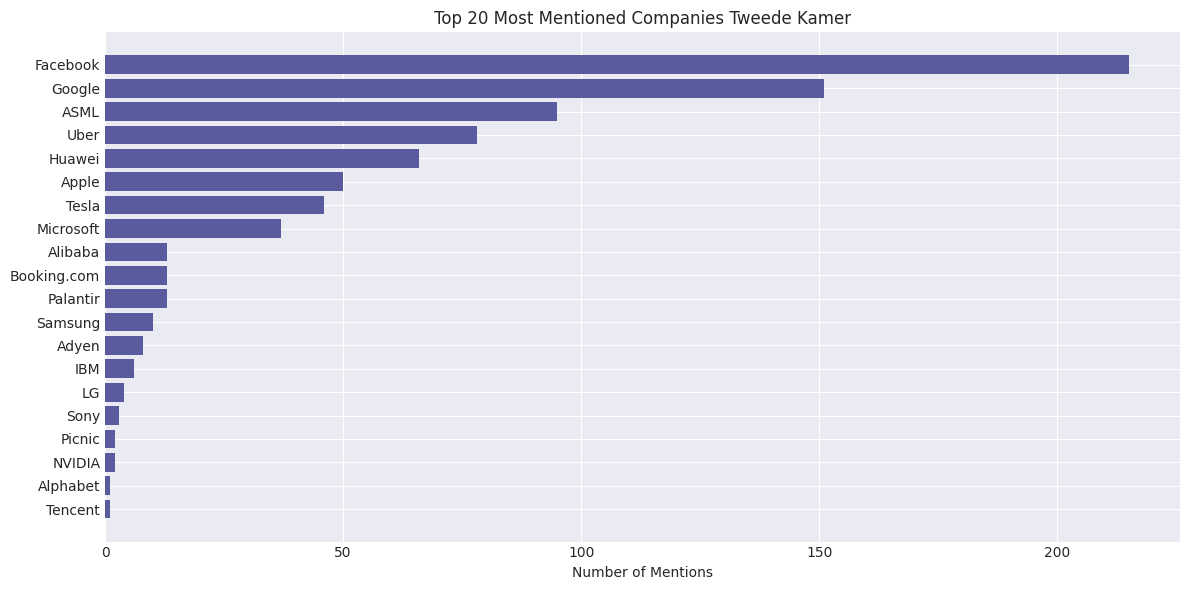

In [26]:

from collections import Counter
import matplotlib.pyplot as plt
import matplotx

# Example: df['company_hits'] contains dictionaries like {'Apple': 2, 'Google': 1, ...}

# Aggregate counts across all rows
total_counts = Counter()
for hits in tk['company_hits']:
    total_counts.update(hits)

# Convert to DataFrame for plotting
company_counts_df = pd.DataFrame(total_counts.items(), columns=['Company', 'Mentions'])
company_counts_df = company_counts_df.sort_values(by='Mentions', ascending=False)

# Plot top 20 companies
top_n = 20
plt.figure(figsize=(12,6))
plt.style.use(matplotx.styles.pacoty)
plt.barh(
    company_counts_df['Company'][:top_n][::-1],  # reverse for largest on top
    company_counts_df['Mentions'][:top_n][::-1],
)
plt.xlabel("Number of Mentions")
plt.title(f"Top {top_n} Most Mentioned Companies Tweede Kamer")
plt.tight_layout()
plt.show()
